In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv('Iris.csv')



In [4]:
# Drop Id column if present
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

In [5]:
# Basic Inspection
print("=== DATASET INFO ===")
df.info()



=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# SUMMARY STATISTICS

In [6]:
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())




=== SUMMARY STATISTICS ===
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


# SAMPLE DATA

In [7]:
print("\n=== SAMPLE DATA ===")
print(df.sample(5))




=== SAMPLE DATA ===
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
32             5.2           4.1            1.5           0.1      Iris-setosa
73             6.1           2.8            4.7           1.2  Iris-versicolor
29             4.7           3.2            1.6           0.2      Iris-setosa
119            6.0           2.2            5.0           1.5   Iris-virginica
37             4.9           3.1            1.5           0.1      Iris-setosa


# MISSING VALUES

In [8]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== MISSING VALUES ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


# Check duplicate

In [9]:
# Check and drop duplicate rows
print(f"Duplicates count before dropping: {df.duplicated().sum()}")


Duplicates count before dropping: 3


#drop duplicate rows

In [10]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Duplicates count after dropping: {df.duplicated().sum()}")
print(f"Dataset shape after dropping duplicates: {df.shape}")

Duplicates count after dropping: 0
Dataset shape after dropping duplicates: (147, 5)


In [11]:
df1=df.copy()

#Step 3: Outlier Detection (Fences & Outlier Count)

In [12]:
features = [col for col in df.columns if col != 'Species']
fences = {}

print("=== OUTLIER DETECTION (BEFORE CAPPING) ===")
for col in features:
    # Percentile calculation
    q1 = df1[col].quantile(0.25)
    q3 = df1[col].quantile(0.75)
    iqr = q3 - q1

    # Define upper and lower fences
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)
    fences[col] = (lower_fence, upper_fence)

    # Count outliers outside fences
    min_outliers = df1[df1[col] < lower_fence].shape[0]
    max_outliers = df1[df1[col] > upper_fence].shape[0]

    print(f"Feature: {col}")
    print(f"  └─ Lower Fence ({lower_fence:.2f}) -> Outliers count: {min_outliers}")
    print(f"  └─ Upper Fence ({upper_fence:.2f}) -> Outliers count: {max_outliers}\n")

=== OUTLIER DETECTION (BEFORE CAPPING) ===
Feature: SepalLengthCm
  └─ Lower Fence (3.15) -> Outliers count: 0
  └─ Upper Fence (8.35) -> Outliers count: 0

Feature: SepalWidthCm
  └─ Lower Fence (2.05) -> Outliers count: 1
  └─ Upper Fence (4.05) -> Outliers count: 3

Feature: PetalLengthCm
  └─ Lower Fence (-3.65) -> Outliers count: 0
  └─ Upper Fence (10.35) -> Outliers count: 0

Feature: PetalWidthCm
  └─ Lower Fence (-1.95) -> Outliers count: 0
  └─ Upper Fence (4.05) -> Outliers count: 0



In [13]:
# Store uncapped min/max values for post-capping testing
old_bounds = {col: (df1[col].min(), df1[col].max()) for col in features}

# Cap values outside upper/lower fences
for col in features:
    l_fence, u_fence = fences[col]
    df1[col] = np.clip(df1[col], l_fence, u_fence)

print("Outlier capping complete across all numerical features.")

Outlier capping complete across all numerical features.


#Step 4: Cap Outliers using Percentile Fences

In [14]:
print("=== OUTLIER CAPPING TEST (MIN / MAX COMPARISON) ===")

for col in features:
    l_fence, u_fence = fences[col]
    old_min, old_max = old_bounds[col]
    new_min = df1[col].min()
    new_max = df1[col].max()

    print(f"--- Feature: {col} ---")
    print(f"  Lower Fence: {l_fence:.2f}  |  Old Min: {old_min:.2f}  -->  New Min: {new_min:.2f}")
    print(f"  Upper Fence: {u_fence:.2f}  |  Old Max: {old_max:.2f}  -->  New Max: {new_max:.2f}\n")

=== OUTLIER CAPPING TEST (MIN / MAX COMPARISON) ===
--- Feature: SepalLengthCm ---
  Lower Fence: 3.15  |  Old Min: 4.30  -->  New Min: 4.30
  Upper Fence: 8.35  |  Old Max: 7.90  -->  New Max: 7.90

--- Feature: SepalWidthCm ---
  Lower Fence: 2.05  |  Old Min: 2.00  -->  New Min: 2.05
  Upper Fence: 4.05  |  Old Max: 4.40  -->  New Max: 4.05

--- Feature: PetalLengthCm ---
  Lower Fence: -3.65  |  Old Min: 1.00  -->  New Min: 1.00
  Upper Fence: 10.35  |  Old Max: 6.90  -->  New Max: 6.90

--- Feature: PetalWidthCm ---
  Lower Fence: -1.95  |  Old Min: 0.10  -->  New Min: 0.10
  Upper Fence: 4.05  |  Old Max: 2.50  -->  New Max: 2.50



#Step 5: Test Outlier Capping

In [16]:
    # Count outliers outside fences
    min_outliers = df1[df1[col] < lower_fence].shape[0]
    max_outliers = df1[df1[col] > upper_fence].shape[0]
   # Add this print line:
print(f"Feature: {col} | Below Lower Fence: {min_outliers} | Above Upper Fence: {max_outliers}")

Feature: PetalWidthCm | Below Lower Fence: 0 | Above Upper Fence: 0


#Step 6: Exploratory Data Analysis (Bivariate & Multivariate)

/tmp/ipykernel_797/4113264861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_797/4113264861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_797/4113264861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Species', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_797/4113264861.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

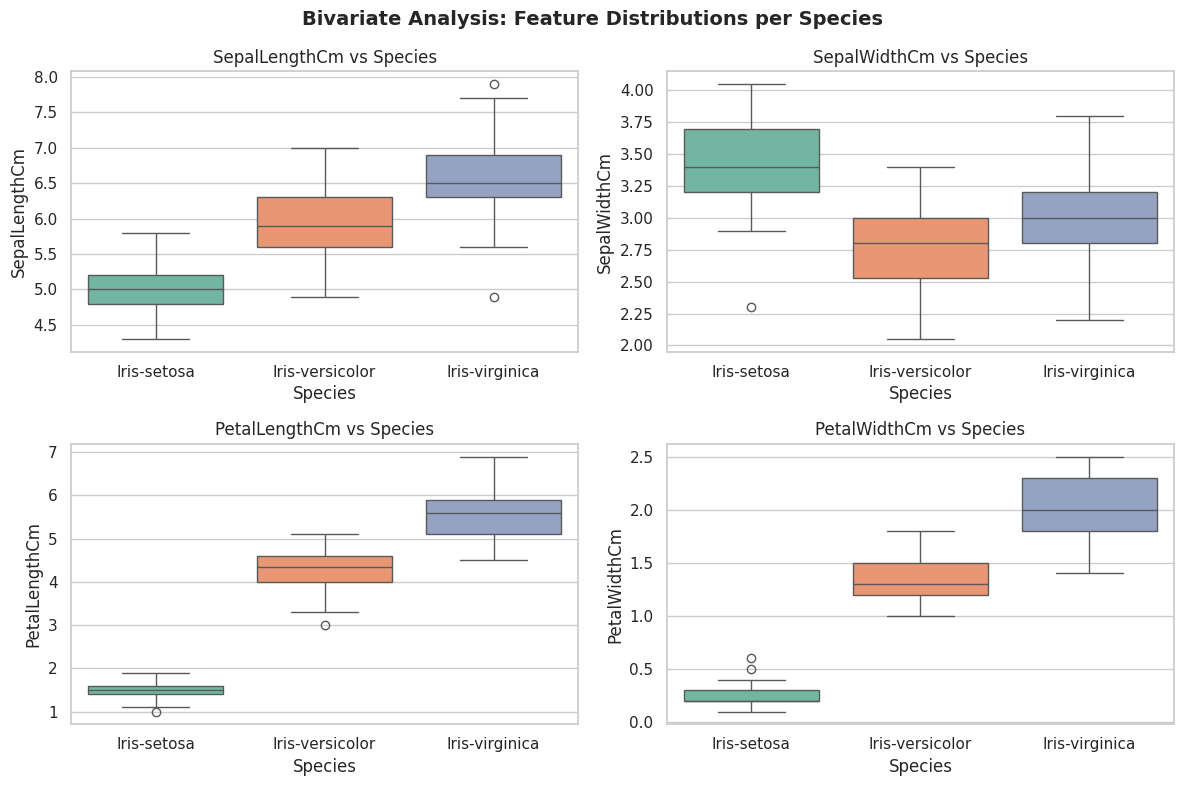

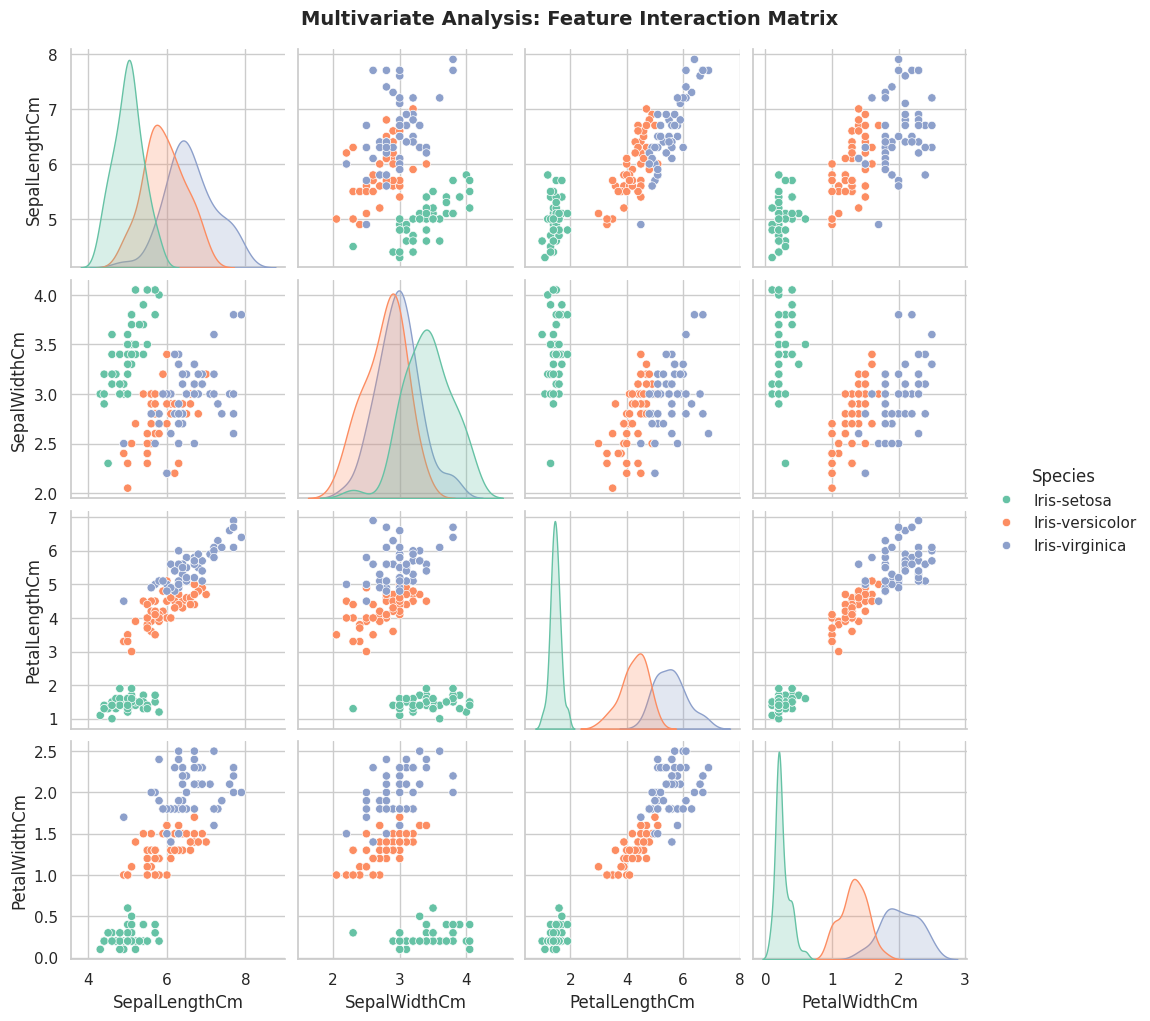

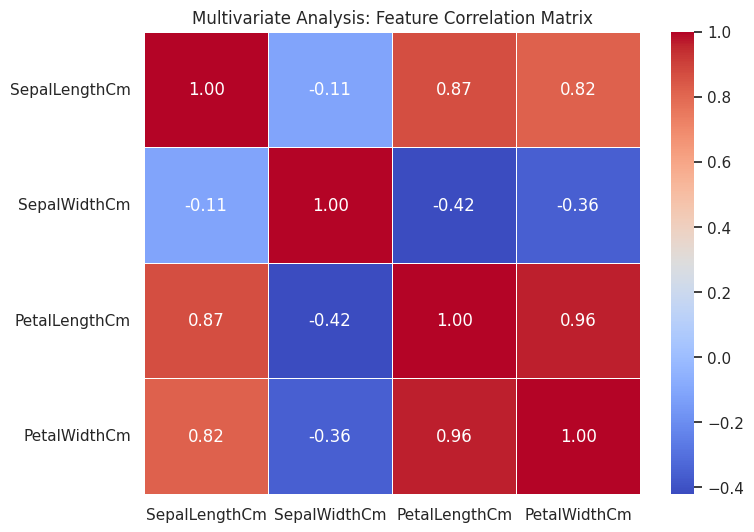

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Bivariate Analysis: Feature Distributions per Species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Bivariate Analysis: Feature Distributions per Species', fontsize=14, fontweight='bold')

for idx, col in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df1, x='Species', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Species')

plt.tight_layout()
plt.show()

# 2. Multivariate Analysis: Pairplot
sns.pairplot(df1, hue='Species', palette='Set2')
plt.suptitle('Multivariate Analysis: Feature Interaction Matrix', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# 3. Multivariate Analysis: Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df1 = df1.select_dtypes(include=[np.number])
sns.heatmap(numeric_df1.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Multivariate Analysis: Feature Correlation Matrix')
plt.show()

#Step 7: Train/Test Split & Standardization

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate Features (X) and Target (y)
X = df.drop(columns=['Species'])
y = df['Species']

# 2. Train / Test Split (Stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardization (Mean = 0, Standard Deviation = 1)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print("\nFirst 3 rows of standardized training features:")
print(X_train_scaled.head(3))

X_train shape: (117, 4)
X_test shape: (30, 4)

First 3 rows of standardized training features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      -0.040953     -0.743554       0.179257     -0.279931
1      -0.391551     -0.967770       0.349770     -0.015803
2       0.543377     -0.295122       1.031820      0.776584


#Step 8: Train the Multinomial Logistic Regression Model

In [19]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize Multinomial Logistic Regression
# multi_class='multinomial' optimizes loss across all 3 classes simultaneously
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=200,
    random_state=42
)

# 2. Fit model ONLY on training data
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#Step 9: Predictions & Performance Evaluation

=== TEST ACCURACY: 93.33% ===

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



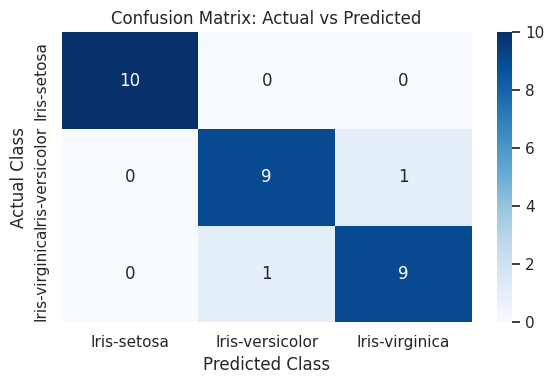

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Class Predictions & Probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# 2. Overall Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"=== TEST ACCURACY: {acc * 100:.2f}% ===\n")

# 3. Precision, Recall, F1-Score Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

#Step 10: Inspect Model Coefficients (Feature Importance per Class)

In [21]:
# Create DataFrame showing learned weights for each species
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=model.classes_
)

print("=== LEARNED COEFFICIENTS (CLASS WEIGHTS) ===")
print(coef_df)

=== LEARNED COEFFICIENTS (CLASS WEIGHTS) ===
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Iris-setosa          -1.063303      1.024614      -1.796998     -1.679634
Iris-versicolor       0.497195     -0.368820      -0.177063     -0.779381
Iris-virginica        0.566107     -0.655794       1.974061      2.459015
